In [1]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from PIL import Image
import os
from paddle.vision.transforms import functional as F
import xml.dom.minidom

In [2]:
def rect_to_xml(base_info, objects, base_keys, bndbox_keys, save_xml_path):
      
  base_info_dict = base_info
  objectList = objects
  base_keys = base_keys
  bndbox_keys = bndbox_keys
  
  save_xml_name = save_xml_path
  
  #在内存中创建一个空的文档
  doc = xml.dom.minidom.Document() 
  #创建一个根节点Managers对象
  root = doc.createElement('annotation') 
  #将根节点添加到文档对象中
  doc.appendChild(root) 

  folder = doc.createElement('folder')
  folder.appendChild(doc.createTextNode(base_info_dict['folder']))
  root.appendChild(folder)

  filename = doc.createElement('filename')
  filename.appendChild(doc.createTextNode(base_info_dict['filename']))
  root.appendChild(filename)

  path = doc.createElement('path')
  path.appendChild(doc.createTextNode(base_info_dict['path']))
  root.appendChild(path)

  source = doc.createElement('source')
  database = doc.createElement('database')
  database.appendChild(doc.createTextNode(base_info_dict['database']))
  source.appendChild(database)
  root.appendChild(source)

  size = doc.createElement('size')
  width = doc.createElement('width')
  width.appendChild(doc.createTextNode(base_info_dict['width']))
  height = doc.createElement('height')
  height.appendChild(doc.createTextNode(base_info_dict['height']))
  depth = doc.createElement('depth')
  depth.appendChild(doc.createTextNode(base_info_dict['depth']))
  size.appendChild(width); size.appendChild(height); size.appendChild(depth)
  root.appendChild(size)

  segmented = doc.createElement('segmented')
  segmented.appendChild(doc.createTextNode(base_info_dict['segmented']))
  root.appendChild(segmented)

  for box in objectList :
    nodeObject = doc.createElement('object')
    
    for base_key in base_keys:
          subnode = doc.createElement(base_key); subnode.appendChild(doc.createTextNode(str(box[base_key])));
          nodeObject.appendChild(subnode)
    
    bndbox = doc.createElement('bndbox')
    for bndbox_key in bndbox_keys:
      subNode = doc.createElement(bndbox_key); subNode.appendChild(doc.createTextNode(str(box['bndbox'][bndbox_key])))
      bndbox.appendChild(subNode)
    nodeObject.appendChild(bndbox)

    root.appendChild(nodeObject)
    
    #开始写xml文档
  fp = open(save_xml_name, 'w')
  doc.writexml(fp, indent='\t', addindent='\t', newl='\n', encoding="utf-8")
  fp.close()


In [3]:
mask_img_path = r'F:\data1\gtFine'
src_img_path = r'F:\data1\leftImg8bit'
imgs_name = []
for _item in os.listdir(mask_img_path):
    if _item.split('.')[-1] in ['jpg', 'png', 'bmp', 'jpeg']:
        imgs_name.append(_item)

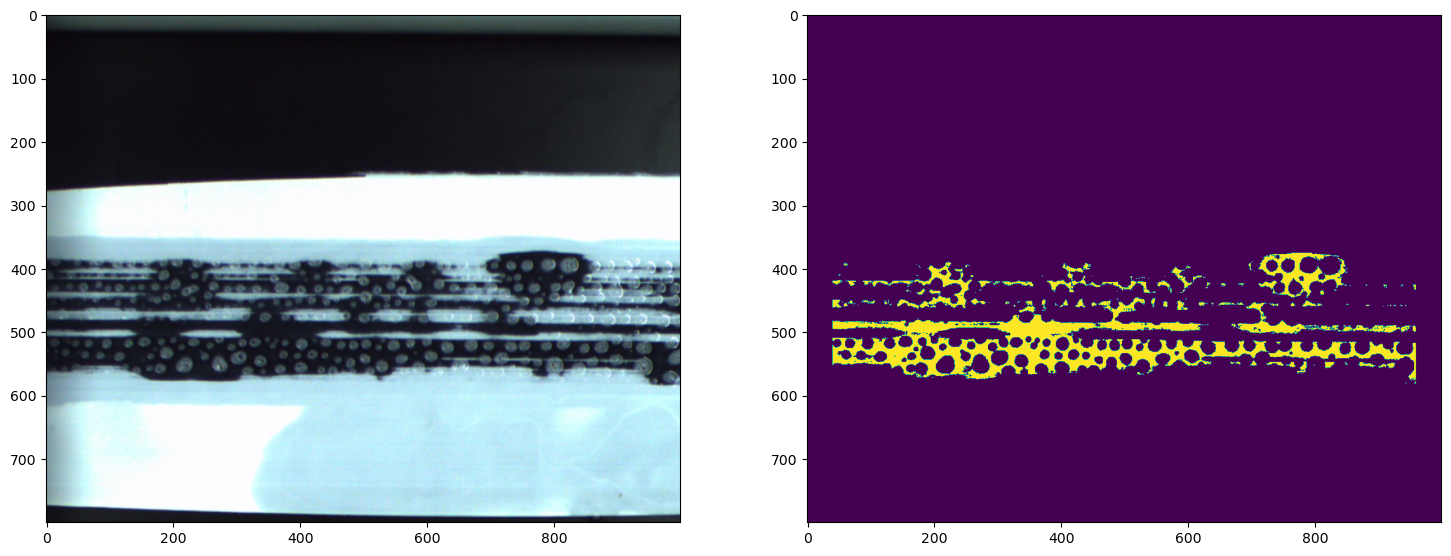

In [4]:
img = np.array(Image.open(os.path.join(mask_img_path, '495.png')))
src_img = np.array(Image.open(os.path.join(src_img_path, '495.jpeg')))
plt.figure(figsize=(18,9))
plt.subplot(1,2,1)
plt.imshow(src_img)
plt.subplot(1,2,2)
plt.imshow(img)

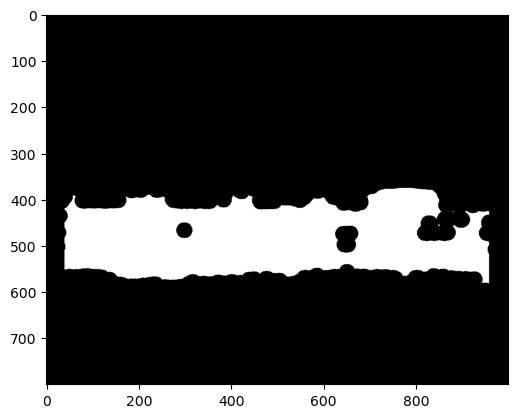

In [5]:
new_img = np.zeros_like(img, dtype=np.uint8)
new_img[img == 1] = 255

se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))
new_img = cv2.morphologyEx(new_img, cv2.MORPH_CLOSE, se)
plt.imshow(new_img, cmap='gray')

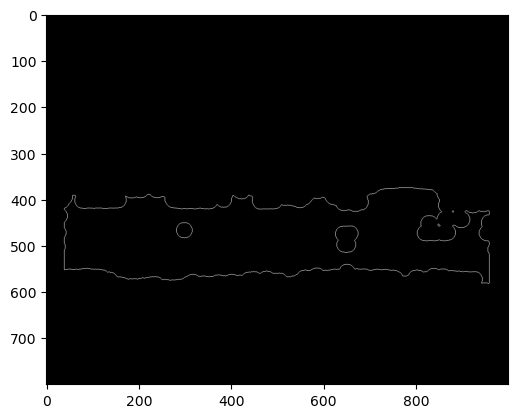

In [6]:
# edge = cv2.Canny(new_img, 200, 300)
edge = cv2.Laplacian(new_img, -1)
plt.imshow(edge, cmap='gray')

In [7]:
#找轮廓并排序
contours, hierarchy	= cv2.findContours(edge, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE )

contours_size = np.array([len(s) for s in contours ])
sort_index = np.argsort(-contours_size) #返回从大到小的索引,降序排列
idx = sort_index[0] #取一个轮廓
print(len(contours))

3


In [15]:
def isInRect(rect1, rect2):
    # 判断rect2是否在rect1内
    leftx1, lefty1, rightx1, righty1 = rect1[0], rect1[1], rect1[0]+rect1[2], rect1[1]+rect1[3]
    leftx2, lefty2, rightx2, righty2 = rect2[0], rect2[1], rect2[0]+rect2[2], rect2[1]+rect2[3]
    if (leftx1 == leftx2 and lefty1 == lefty2 ) and (rightx1 == rightx2 and righty1 == righty2):
        return False
    if (leftx1 <= leftx2 and lefty1 <= lefty2 ) and (rightx1 >= rightx2 and righty1 >= righty2):
        return True
    else:
        return False
    
def check_mix(rectList, min_len=2):
    _rectList1 = []
    for _rect in rectList:
        if _rect[2] >= min_len and _rect[3] >= min_len:
            _rectList1.append(_rect)
            
    _rectList1_copy = _rectList1.copy()
  
    for i in range(0, len(_rectList1)):
        _rect1 = _rectList1[i]
        temp_ = []
        for _rect2 in _rectList1_copy:
            _flag = isInRect(_rect1, _rect2)
            if _flag == True:
                temp_.append(_rect2)
        for _waitRe in temp_:
            _rectList1_copy.remove(_waitRe)
        
    return _rectList1_copy

In [16]:
rectList = []
for _idx in sort_index:
    rect = cv2.boundingRect(contours[_idx])
    rectList.append(rect)
    
rectList_deal = check_mix(rectList)
print(rectList)
print(rectList_deal)

[(39, 375, 921, 208), (879, 425, 4, 4), (848, 453, 6, 6)]
[(39, 375, 921, 208)]


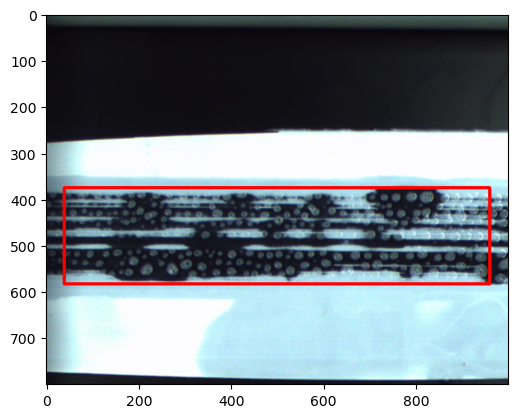

In [17]:
_src = src_img.copy()
for rect in rectList_deal:    
    cv2.rectangle(_src, (rect[0], rect[1]), (rect[0]+rect[2], rect[1]+rect[3]), color=(255, 0, 0), thickness=5)
plt.imshow(_src)
plt.show()

In [12]:
print(isInRect((39, 375, 921, 208), (848, 453, 6, 6)))

True


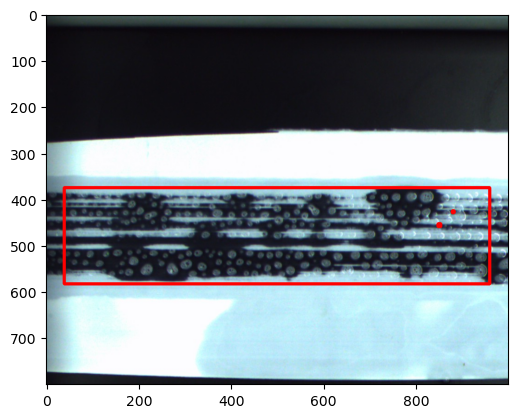

In [74]:
_src = src_img.copy()
for rect in rectList:    
    cv2.rectangle(_src, (rect[0], rect[1]), (rect[0]+rect[2], rect[1]+rect[3]), color=(255, 0, 0), thickness=5)
plt.imshow(_src)
plt.show()

In [ ]:
rectList = []
for _idx in sort_index:
    rect = cv2.boundingRect(contours[_idx])
    rectList.append(rect)
    
_rectList1 = []
min_len = 6
for _rect in rectList:
    if _rect[2] >= min_len and _rect[3] >= min_len:
        _rectList1.append(_rect)
print(len(_rectList1))

IoU_max = 0.95
_rectList1_copy = _rectList1.copy()
_rectList2 = []
for i in range(0, len(_rectList1)):
    pass

In [ ]:
# def IoU_Rect(rect1, rect2):



In [ ]:
base_info_dict = {'folder':'newImg', 'filename':'1.jpg', 'path':r'F:\data1\newImg\1.jpg', 
                    'database':'Unknown', 'width':'1000', 'height':'800', 'depth':'3', 'segmented':'0'}
objectList = [
    {'name':'fg', 'pose':'Unspecified', 'truncated':'0', 'difficult':0, 'bndbox':{'xmin':'219', 'ymin':'389', 'xmax':'555', 'ymax':'538'}}
  ]
base_keys = ['name', 'pose', 'truncated', 'difficult']
bndbox_keys = ['xmin', 'ymin', 'xmax', 'ymax']
  
save_xml_name = 'my112.xml'

rect_to_xml(base_info_dict, objectList, base_keys, bndbox_keys, save_xml_name)

In [ ]:
base_info_dict = {'folder':'newImg', 'filename':'1.jpg', 'path':r'F:\data1\newImg\1.jpg', 
                    'database':'Unknown', 'width':'1000', 'height':'800', 'depth':'3', 'segmented':'0'}

h, w, ddp = src_img.shape
base_info_dict['folder'] = 'leftImg8bit'; base_info_dict['filename']='63.jpeg'
base_info_dict['path'] = r'F:\data1\leftImg8bit\63.jpeg'
base_info_dict['width'] = str(w); base_info_dict['height'] = str(h); base_info_dict['depth'] = str(ddp)

objectList = []
for rect in rectList:
      xmin, ymin, xmax, ymax = str(rect[0]), str(rect[1]), str(rect[0]+rect[2]), str(rect[1]+rect[3])
      sub_dict = {'name':'fall', 'pose':'Unspecified', 'truncated':'0', 'difficult':0,
                  'bndbox':{'xmin':xmin, 'ymin':ymin, 'xmax':xmax, 'ymax':ymax}}
      objectList.append(sub_dict)
base_keys = ['name', 'pose', 'truncated', 'difficult']
bndbox_keys = ['xmin', 'ymin', 'xmax', 'ymax']

save_xml_name = '63.xml'

print(src_img.shape)
print(len(objectList))

In [ ]:
rect_to_xml(base_info_dict, objectList, base_keys, bndbox_keys, save_xml_name)

In [ ]:
_src = src_img.copy()
for rect in rectList:    
    cv2.rectangle(_src, (rect[0], rect[1]), (rect[0]+rect[2], rect[1]+rect[3]), color=(255, 0, 0), thickness=5)
plt.imshow(_src)
plt.show()

In [ ]:
_src = src_img.copy()
for _idx in sort_index:
    rect = cv2.boundingRect(contours[_idx])
    
    cv2.drawContours(_src, contours, _idx, (0,255,0), thickness=3) #画原轮廓，绿色
    cv2.rectangle(_src, (rect[0], rect[1]), (rect[0]+rect[2], rect[1]+rect[3]), color=(255, 0, 0), thickness=5)
plt.imshow(_src)
plt.show()